# Regression in Python
## Notebook 2: Multiple Linear Regression

**Before starting:** This notebook builds on Notebook 1.  
You should already be comfortable with $x$, $y$, $\hat{y}$, residual, $b_0$, $b_1$, $R^2$, and $r$ before continuing.

---

### Learning goals

By the end of this notebook, you should be able to:

- explain what a multiple linear regression model is,
- distinguish simple linear regression from multiple linear regression,
- write the multiple linear regression equation,
- fit a multiple linear regression model using `sklearn`,
- interpret the intercept and slopes,
- explain the meaning of "holding other variables constant,"
- explain what dummy variables and one-hot encoding are,
- identify the **reference / baseline category** in a regression model,
- explain why a controlled comparison differs from a raw group average,
- compare models using both **$R^2$** and **Adjusted $R^2$**,
- make predictions using a multiple linear regression model.

## 1. Quick review: simple vs. multiple regression

| Topic | Simple Linear Regression | Multiple Linear Regression |
|---|---|---|
| Number of predictors | 1 | 2 or more |
| Model form | $\hat{y} = b_0 + b_1 x$ | $\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \cdots + b_p x_p$ |
| Slope interpretation | Change in $\hat{y}$ for a 1-unit increase in $x$ | Change in $\hat{y}$ for a 1-unit increase in one predictor, **holding the other predictors constant** |

Recall the notation from Notebook 1:

- $x$ = **feature** / **independent** variable
- $y$ = target / response / **dependent** variable (observed)
- $\hat{y}$ = predicted value of $y$

The phrase **"holding all other variables constant"** is the most important idea in multiple regression.  
We will explain exactly what it means — with numbers — in this notebook.

## 2. The multiple linear regression equation

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \cdots + b_p x_p$$

where:

- $b_0$ is the **intercept** — predicted value of $y$ when all inputs equal zero
- $b_1, b_2, \dots, b_p$ are the **slopes**
- $x_1, x_2, \dots, x_p$ are the **input features**

Just like in Notebook 1, `sklearn` uses the **least squares method** to minimise:

$$SSE = \sum (y - \hat{y})^2$$

## 3. House price example

In this notebook, we predict **house price** (`HousePrice`) using:

| Variable | Role | Description |
|---|---|---|
| `SizeSqFt` | Input $x_1$ | House size in square feet |
| `Bedrooms` | Input $x_2$ | Number of bedrooms |
| `Age` | Input $x_3$ | Age of the house in years |
| `Location` | Categorical input | Neighbourhood type: `Rural`, `Suburban`, or `Urban` |
| `HousePrice` | Target $y$ | Sale price in **thousands of dollars** |

> `HousePrice = 430` means **\$430,000**.

### The real-world story in this dataset

This dataset reflects a well-known pattern in real housing markets:

- **Urban** houses are **small** (limited land, dense neighbourhoods) but **very expensive** — people pay a large premium to live close to jobs, transit, and amenities.
- **Rural** houses are **large** (more land, more space) but **cheap** — you get more room, but the location carries less economic value.
- **Suburban** houses sit in between on both size and price.

This pattern — **Urban = small but expensive, Rural = large but cheap** — creates an interesting situation where raw averages can be misleading.  
We will return to this idea when we interpret the location coefficients in Section 10.

In [1]:
# Import the packages we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression # This is the most important package (sklearn.linear_model)
                                                  # LinearRegression is a method

sns.set_theme(style="whitegrid")

In [3]:
# Create the house price dataset
# Urban:    small (850–1200 sqft),  expensive ($410–498k)
# Suburban: medium (1500–1800 sqft), medium price ($288–352k)
# Rural:    large (2100–2600 sqft),  cheap ($238–295k)
housing = pd.DataFrame({
    "SizeSqFt": [900,  1050, 1200, 1100, 850,
                 1500, 1650, 1750, 1600, 1800,
                 2200, 2400, 2600, 2100, 2500],
    "Bedrooms": [1,    2,    2,    1,    2,
                 3,    3,    3,    3,    4,
                 4,    4,    5,    4,    5],
    "Age":      [5,    8,    3,    10,   6,
                 12,   15,   10,   18,   14,
                 25,   30,   20,   28,   22],
    "Location": ["Urban",    "Urban",    "Urban",    "Urban",    "Urban",
                 "Suburban", "Suburban", "Suburban", "Suburban", "Suburban",
                 "Rural",    "Rural",    "Rural",    "Rural",    "Rural"],
    "HousePrice": [430, 465, 498, 442, 410,
                   298, 318, 335, 288, 352,
                   248, 275, 295, 238, 282]
})

housing # is a dataframe from the dictionary

,SizeSqFt,Bedrooms,Age,Location,HousePrice
0,900,1,5,Urban,430
1,1050,2,8,Urban,465
2,1200,2,3,Urban,498
3,1100,1,10,Urban,442
4,850,2,6,Urban,410
5,1500,3,12,Suburban,298
6,1650,3,15,Suburban,318
7,1750,3,10,Suburban,335
8,1600,3,18,Suburban,288
9,1800,4,14,Suburban,352


## 4. Exploring the data

Before fitting any model, let us look at the data visually and numerically.

In [4]:
# Average characteristics by location
summary = housing.groupby("Location")[["SizeSqFt", "Bedrooms", "Age", "HousePrice"]].mean().round(1)
summary = summary.loc[["Rural", "Suburban", "Urban"]]
print("Average characteristics by location:")
print(summary)
print()

# Price per square foot
print("Average price per square foot:")
for loc in ["Rural", "Suburban", "Urban"]:
    sub = housing[housing["Location"] == loc]
    ppsf = (sub["HousePrice"] * 1000 / sub["SizeSqFt"]).mean()
    print(f"  {loc:10s}: ${ppsf:,.0f} per sq ft")

Average characteristics by location:
          SizeSqFt  Bedrooms   Age  HousePrice
Location                                      
Rural       2360.0       4.4  25.0       267.6
Suburban    1660.0       3.2  13.8       318.2
Urban       1020.0       1.6   6.4       449.0

Average price per square foot:
  Rural     : $113 per sq ft
  Suburban  : $192 per sq ft
  Urban     : $444 per sq ft


The table confirms the real-world pattern:

- **Urban** houses are the **smallest** (~1,020 sq ft) yet the **most expensive**, at ~\$444 per sq ft.
- **Rural** houses are the **largest** (~2,360 sq ft) yet the **cheapest**, at only ~\$113 per sq ft.
- **Suburban** is in between on all dimensions.

People are paying for **location**, not for space.

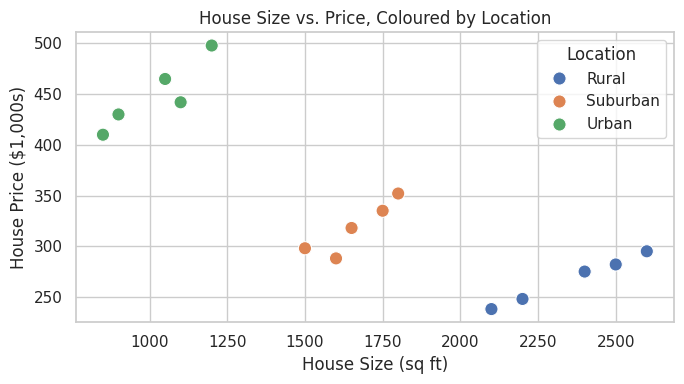

In [ ]:
# Scatter plot: size vs. price, coloured by location
plt.figure(figsize=(7, 4))
sns.scatterplot(data=housing, x="SizeSqFt", y="HousePrice",
                hue="Location", hue_order=["Rural", "Suburban", "Urban"], s=90)
plt.xlabel("House Size (sq ft)")
plt.ylabel("House Price ($1,000s)")
plt.title("House Size vs. Price, Coloured by Location")
plt.tight_layout()
plt.show()

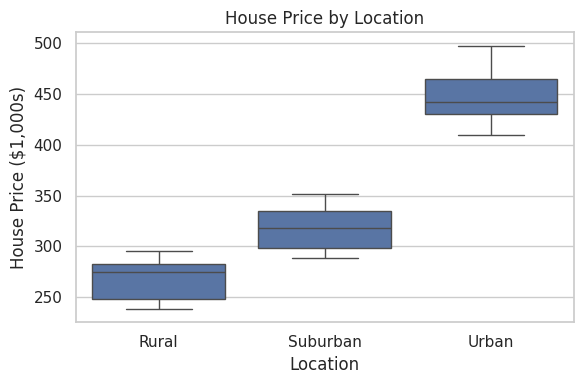

In [ ]:
# Box plot: price by location
plt.figure(figsize=(6, 4))
sns.boxplot(data=housing, x="Location", y="HousePrice",
            order=["Rural", "Suburban", "Urban"])
plt.xlabel("Location")
plt.ylabel("House Price ($1,000s)")
plt.title("House Price by Location")
plt.tight_layout()
plt.show()

The scatter plot shows three separate clusters.  
Urban houses (upper-left: small and expensive) are completely separated from Rural houses (lower-right: large and cheap).  
Size alone cannot explain price — location is doing a lot of the work.

## 5. Model 1 — Numeric features only

We first fit a model using only the three numeric features: `SizeSqFt`, `Bedrooms`, and `Age`.  
We leave out `Location` for now — this gives us a comparison point for later.

In [7]:
# Define y once — not redefined anywhere below
y = housing["HousePrice"]

# Numeric-only feature matrix
X_num = housing[["SizeSqFt", "Bedrooms", "Age"]] # X has to be a 2d array --> [[ ..... ]]

# Fit Model 1
numeric_model = LinearRegression()
numeric_model.fit(X_num, y)  # train a model, numeric_model

#we can get the intercept and coefficients for sizesqft, bedrooms and age

b0_num   = numeric_model.intercept_ #intercept value
coef_num = numeric_model.coef_ #this is the fastest way to get the coefficients.

print(coef_num)#this is the fastest way to get the coefficients.

coef_num = pd.Series(numeric_model.coef_, index=X_num.columns) #cofficients - make makes your output look nice

r2_num   = numeric_model.score(X_num, y) # score() returns  R^2 value

print(f"Intercept (b0): {b0_num:.4f}")
print("\nCoefficients:")
print(coef_num)
print(f"\nR\u00b2 = {r2_num:.4f}")

[  0.04767086 -34.64191371  -7.34338882]
Intercept (b0): 481.7219

Coefficients:
SizeSqFt     0.047671
Bedrooms   -34.641914
Age         -7.343389
dtype: float64

R² = 0.8096


## 6. Interpreting Model 1

$$\hat{y} = b_0 + b_1(\text{SizeSqFt}) + b_2(\text{Bedrooms}) + b_3(\text{Age})$$

Each slope is interpreted **holding all other variables constant**.

In [ ]:
# Plain-language interpretation of Model 1
print("Model 1 coefficient interpretation")
print("-" * 50)
print(f"SizeSqFt = {coef_num['SizeSqFt']:.4f}")
print(f"  \u2192 Each additional sq ft changes predicted price by ${coef_num['SizeSqFt']:.4f}k,")
print("    holding Bedrooms and Age constant.")
print()
print(f"Bedrooms = {coef_num['Bedrooms']:.4f}")
print(f"  \u2192 Each additional bedroom changes predicted price by ${coef_num['Bedrooms']:.4f}k,")
print("    holding SizeSqFt and Age constant.")
print()
print(f"Age = {coef_num['Age']:.4f}")
print(f"  \u2192 Each additional year of age changes predicted price by ${coef_num['Age']:.4f}k,")
print("    holding SizeSqFt and Bedrooms constant.")

Model 1 coefficient interpretation
--------------------------------------------------
SizeSqFt = 0.0477
  → Each additional sq ft changes predicted price by $0.0477k,
    holding Bedrooms and Age constant.

Bedrooms = -34.6419
  → Each additional bedroom changes predicted price by $-34.6419k,
    holding SizeSqFt and Age constant.

Age = -7.3434
  → Each additional year of age changes predicted price by $-7.3434k,
    holding SizeSqFt and Bedrooms constant.


### Wait — the Bedrooms coefficient is negative?

Look at the `Bedrooms` coefficient in Model 1. It is **strongly negative** — which seems strange.  
Surely a house with more bedrooms should cost more, not less?

This is a sign of **confounding** — when a missing variable distorts the estimated effect of another variable.

Here is what is happening in this dataset:

- **Urban** houses have very **few bedrooms** (1–2) but are very **expensive** (\$410–498k)
- **Rural** houses have many **bedrooms** (4–5) but are **cheap** (\$238–295k)

When the model only sees `SizeSqFt`, `Bedrooms`, and `Age` — **without knowing about `Location`** — it sees a pattern like this:

> "Houses with 1–2 bedrooms tend to be expensive. Houses with 4–5 bedrooms tend to be cheap."

So it concludes that more bedrooms means lower price. **But that is wrong** — the real reason is location.  
The few-bedroom houses are expensive *because they are Urban*, not because they have few bedrooms.

Once we add `Location` to the model in Model 2, this confusion goes away.  
The model will correctly understand that Urban houses are expensive *because of their location*, and the `Bedrooms` coefficient will become **positive**.

### Mini exercise 1

Using the output above:

1. Which coefficient is **negative**? Does this make intuitive sense on its own?
2. Based on the explanation above, what is causing the `Bedrooms` coefficient to appear negative?
3. What do you expect will happen to the `Bedrooms` coefficient once `Location` is added?

**Mini exercise 1 — Answers**

1. Both `Bedrooms` and `Age` are negative. `Bedrooms` being negative does **not** make intuitive sense — we would normally expect more bedrooms to increase price.
2. `Location` is missing from the model. Urban houses have few bedrooms but are expensive; Rural houses have many bedrooms but are cheap. Without knowing about `Location`, the model incorrectly concludes that more bedrooms is associated with lower price.
3. Once `Location` is added in Model 2, the `Bedrooms` coefficient should become **positive** — because the model can now correctly separate the location effect from the bedroom effect.


## 7. Why we cannot use `Location` directly

`Location` contains text categories — `"Rural"`, `"Suburban"`, `"Urban"`.  
`sklearn`'s `LinearRegression` requires **all input features to be numeric**.  
We must convert `Location` into numbers before including it in the model.

The standard method is called **one-hot encoding** (also called **dummy variables**).

## 8. Dummy variables and one-hot encoding

### Idea

A categorical variable with several categories is replaced by several **binary (0/1) indicator columns** — one per category.

For `Location`, the full set would be:

| Original `Location` | `Location_Rural` | `Location_Suburban` | `Location_Urban` |
|---|---:|---:|---:|
| Rural | 1 | 0 | 0 |
| Suburban | 0 | 1 | 0 |
| Urban | 0 | 0 | 1 |

This is called **one-hot encoding**.

### Why we drop one dummy column

If we kept **all three** dummy columns, one could always be predicted perfectly from the other two.  
For example: if a house is **not** Suburban and **not** Urban, it **must** be Rural.  
That perfect redundancy causes mathematical problems for the model, so we always drop one.

### Reference / baseline category

The dropped category becomes the **reference / baseline category**.  
All other dummy coefficients are then interpreted **relative to that baseline**.

In this notebook, we choose **`Rural` as the baseline** and drop `Location_Rural`.

| `Location_Suburban` | `Location_Urban` | Interpretation |
|---:|---:|---|
| 0 | 0 | Rural (baseline) |
| 1 | 0 | Suburban — compare with Rural |
| 0 | 1 | Urban — compare with Rural |

In [8]:
# Step 1: create all dummy columns
housing_encoded = pd.get_dummies(housing, columns=["Location"],
                                  drop_first=False, dtype=int)

print("All dummy columns created:")
housing_encoded.head()

All dummy columns created:


,SizeSqFt,Bedrooms,Age,HousePrice,Location_Rural,Location_Suburban,Location_Urban
0,900,1,5,430,0,0,1
1,1050,2,8,465,0,0,1
2,1200,2,3,498,0,0,1
3,1100,1,10,442,0,0,1
4,850,2,6,410,0,0,1


In [9]:
# Step 2: drop Location_Rural — makes Rural the reference / baseline category
housing_encoded = housing_encoded.drop(columns=["Location_Rural"])

print("After dropping Location_Rural (Rural = baseline):")
housing_encoded.head()

After dropping Location_Rural (Rural = baseline):


,SizeSqFt,Bedrooms,Age,HousePrice,Location_Suburban,Location_Urban
0,900,1,5,430,0,1
1,1050,2,8,465,0,1
2,1200,2,3,498,0,1
3,1100,1,10,442,0,1
4,850,2,6,410,0,1


The model will now use five predictors:
`SizeSqFt`, `Bedrooms`, `Age`, `Location_Suburban`, `Location_Urban`.

A house with both dummies = 0 is a **Rural** house (the baseline).

## 9. Model 2 — Full model with encoded location

In [10]:
# Define the full feature matrix
X_full = housing_encoded[["SizeSqFt", "Bedrooms", "Age",
                           "Location_Suburban", "Location_Urban"]]

# Fit Model 2
# Note: y was defined in Section 5 and has not been changed
full_model = LinearRegression()
full_model.fit(X_full, y)

b0_full   = full_model.intercept_
coef_full = pd.Series(full_model.coef_, index=X_full.columns)
r2_full   = full_model.score(X_full, y)

print(f"Intercept (b0): {b0_full:.4f}")
print("\nCoefficients:")
print(coef_full)
print(f"\nR\u00b2 = {r2_full:.4f}")

Intercept (b0): -68.6542

Coefficients:
SizeSqFt               0.141609
Bedrooms               4.661765
Age                   -0.738154
Location_Suburban    147.052815
Location_Urban       370.478805
dtype: float64

R² = 0.9808


### Did the Bedrooms coefficient fix itself?

Check the `Bedrooms` coefficient now. It should be **positive** — confirming our prediction from Section 6.  
Once the model knows about `Location`, it correctly separates the location effect from the bedroom effect:

> "Urban houses are expensive **because of their location**, not despite having few bedrooms."  
> "Rural houses are cheap **because of their location**, not because they have many bedrooms."

With that confusion resolved, the model correctly concludes that more bedrooms → higher predicted price.

## 10. Interpreting the location coefficients

Because `Rural` is the reference category, the location coefficients are **relative to Rural**:

- `Location_Suburban` — how Suburban houses compare to Rural houses
- `Location_Urban` — how Urban houses compare to Rural houses

while holding `SizeSqFt`, `Bedrooms`, and `Age` **constant**.

In [11]:
# Plain-language interpretation of location coefficients
print("Location coefficient interpretation (baseline = Rural)")
print("-" * 65)
print(f"Location_Suburban = {coef_full['Location_Suburban']:.4f}")
print("  \u2192 Compared with a Rural house of the SAME size, bedrooms, and age,")
print(f"    a Suburban house is predicted to cost "
      f"${coef_full['Location_Suburban']:.1f}k "
      f"{'more' if coef_full['Location_Suburban'] > 0 else 'less'}.")
print()
print(f"Location_Urban = {coef_full['Location_Urban']:.4f}")
print("  \u2192 Compared with a Rural house of the SAME size, bedrooms, and age,")
print(f"    an Urban house is predicted to cost "
      f"${coef_full['Location_Urban']:.1f}k "
      f"{'more' if coef_full['Location_Urban'] > 0 else 'less'}.")

Location coefficient interpretation (baseline = Rural)
-----------------------------------------------------------------
Location_Suburban = 147.0528
  → Compared with a Rural house of the SAME size, bedrooms, and age,
    a Suburban house is predicted to cost $147.1k more.

Location_Urban = 370.4788
  → Compared with a Rural house of the SAME size, bedrooms, and age,
    an Urban house is predicted to cost $370.5k more.


### Mini exercise 2

Using the output above:

1. How much more is a Suburban house predicted to cost than a Rural house of the **same size, bedrooms, and age**?
2. How much more is an Urban house predicted to cost than a Rural house of the **same size, bedrooms, and age**?
3. Are both location coefficients positive? Does that match the real-world story from Section 3?

**Mini exercise 2 — Answers**

1. A Suburban house is predicted to cost about **\$147.1k more** than a Rural house of the same size, bedrooms, and age.
2. An Urban house is predicted to cost about **\$370.5k more** than a Rural house of the same size, bedrooms, and age.
3. Yes — both coefficients are positive, which matches the real-world story. Urban is most expensive, Suburban is in between, and Rural is the baseline.


## 11. Comparing the two models: $R^2$ and Adjusted $R^2$

### 11.1 $R^2$ comparison

In [ ]:
print(f"R\u00b2 — numeric-only model : {r2_num:.4f}")
print(f"R\u00b2 — full model          : {r2_full:.4f}")
print()
print(f"About {r2_full * 100:.1f}% of the variation in house price")
print("is explained by the full model.")

R² — numeric-only model : 0.8096
R² — full model          : 0.9808

About 98.1% of the variation in house price
is explained by the full model.


The full model explains far more variation. That is a strong signal that `Location` contains important information.

### 11.2 Why $R^2$ alone is not enough for model comparison

Regular $R^2$ will **never decrease** when you add variables — it can only stay the same or go up.  
This is a mathematical fact, not evidence that the model improved.  
Even adding a completely useless random column will slightly increase $R^2$.

So when comparing two models with different numbers of predictors, $R^2$ alone is misleading.

### 11.3 Adjusted $R^2$ — the right tool for model comparison

**Adjusted $R^2$** adds a **penalty** for each extra predictor.  
If a new variable does not contribute enough to justify its presence, adjusted $R^2$ will **decrease**.

$$\bar{R}^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$$

where $n$ = number of observations and $p$ = number of predictors.

| Situation | Use |
|---|---|
| Describing fit of **one specific model** | $R^2$ |
| **Comparing models** with different numbers of predictors | Adjusted $R^2$ |

In [12]:
# Compute Adjusted R-squared for both models
n  = len(housing)
p_num  = X_num.shape[1]    # 3 predictors
p_full = X_full.shape[1]   # 5 predictors

adj_r2_num  = 1 - (1 - r2_num)  * (n - 1) / (n - p_num  - 1)
adj_r2_full = 1 - (1 - r2_full) * (n - 1) / (n - p_full - 1)

print(f"{'':30s} {'Model 1':>12} {'Model 2':>12}")
print(f"{'Predictors (p)':30s} {p_num:>12} {p_full:>12}")
print(f"{'R\u00b2':30s} {r2_num:>12.4f} {r2_full:>12.4f}")
print(f"{'Adjusted R\u00b2':30s} {adj_r2_num:>12.4f} {adj_r2_full:>12.4f}")
print()
print(f"R\u00b2        improved by {(r2_full - r2_num)*100:+.2f} percentage points.")
print(f"Adjusted R\u00b2 improved by {(adj_r2_full - adj_r2_num)*100:+.2f} percentage points.")

                                    Model 1      Model 2
Predictors (p)                            3            5
R²                                   0.8096       0.9808
Adjusted R²                          0.7576       0.9701

R²        improved by +17.12 percentage points.
Adjusted R² improved by +21.25 percentage points.


Adjusted $R^2$ also increases substantially — confirming that `Location` is genuinely earning its place in the model, not just adding complexity.

### Mini exercise 3

1. What is Adjusted $R^2$ for Model 1?
2. What is Adjusted $R^2$ for Model 2?
3. Does Adjusted $R^2$ increase after adding `Location`? Why does this matter?

**Mini exercise 3 — Answers**

1. Adjusted $R^2$ for Model 1 is approximately **0.7576**.
2. Adjusted $R^2$ for Model 2 is approximately **0.9701**.
3. Yes, it increases — and this matters because adjusted $R^2$ penalises extra predictors. The increase tells us `Location` is genuinely earning its place, not just inflating $R^2$ artificially.


## 12. How adding Location changed the numeric coefficients

When we add an important variable to a model, the coefficients of the existing variables can change substantially.  
This is one of the most important lessons in multiple regression.

In [13]:
# Put the shared coefficients side by side for comparison
coef_compare = pd.DataFrame({
    "Model 1 (numeric only)": coef_num,
    "Model 2 (with location)": coef_full[["SizeSqFt", "Bedrooms", "Age"]]
})
coef_compare["Change"] = (
    coef_compare["Model 2 (with location)"] -
    coef_compare["Model 1 (numeric only)"]
)

print(coef_compare.round(4))

          Model 1 (numeric only)  Model 2 (with location)   Change
SizeSqFt                  0.0477                   0.1416   0.0939
Bedrooms                -34.6419                   4.6618  39.3037
Age                      -7.3434                  -0.7382   6.6052


The most dramatic change is in `Bedrooms` — it flips from strongly negative (−34.6) to slightly positive (+4.7).  

This directly illustrates **confounding**: the numeric-only model was attributing the Urban location premium to having few bedrooms, because it could not distinguish between the two effects. Once `Location` was added, the distortion disappeared and each variable was correctly estimated.

### Mini exercise 4

1. Which coefficient changes the most after `Location` is added?
2. In Model 1, `Bedrooms` was negative. In Model 2, it is positive. What caused this flip?
3. Why is it important to include all relevant variables in a regression model?

**Mini exercise 4 — Answers**

1. **`Bedrooms`** changes the most — it flips from −34.6 (Model 1) to +4.7 (Model 2), a change of about 39 units.
2. Confounding. In Model 1, the model could not separate the location effect from the bedroom effect. Urban houses have few bedrooms but are expensive, so the model incorrectly attributed the high price to having few bedrooms. Adding `Location` resolves this.
3. Leaving out a relevant variable distorts the estimated effects of all other variables — as we saw with `Bedrooms`. Including all important variables leads to correct, unbiased estimates.


## 13. Predicting values of $\hat{y}$

Now we use the full model to predict house prices.

Remember:

- $y$ = observed house price  
- $\hat{y}$ = predicted house price  

So in this section, we are looking for:

$
\hat{y}
$

Because the full model was trained using these predictor columns:

- `SizeSqFt`
- `Bedrooms`
- `Age`
- `Location_Suburban`
- `Location_Urban`

our prediction input should use the **same columns**.

Using a complete 2D DataFrame is the clearest approach and helps avoid sklearn warnings.


### Example 1: Predict one house

Suppose we want to predict the price of one house with:

- `SizeSqFt = 1200`
- `Bedrooms = 2`
- `Age = 5`
- `Location = Urban`

Since `Rural` is the baseline category:

- Urban house → `Location_Suburban = 0`, `Location_Urban = 1`


In [14]:
# Predict one house price using the same predictor columns as X_full
one_house = pd.DataFrame({
    "SizeSqFt": [1200],
    "Bedrooms": [2],
    "Age": [5],
    "Location_Suburban": [0],
    "Location_Urban": [1]
})

one_house["PredictedPrice"] = full_model.predict(one_house)

one_house.round(1)


,SizeSqFt,Bedrooms,Age,Location_Suburban,Location_Urban,PredictedPrice
0,1200,2,5,0,1,477.4


In [16]:
full_model.predict ([[1200, 2, 5, 0,1]]) #another way of predicting the housing price (with the warning)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([477.38766891])

In this table:

- the first five columns are the predictor values $X$
- `PredictedPrice` is $\hat{y}$

So this gives the predicted house price for one Urban house.


### Example 2: Predict several houses

Now let us predict prices for several houses at once.

Each house below has the same:

- `SizeSqFt = 1500`
- `Bedrooms = 3`
- `Age = 12`

Only the location changes.


In [18]:
# Predict several house prices at once
new_houses = pd.DataFrame({
    "Location": ["Rural", "Suburban", "Urban"],
    "SizeSqFt": [1500, 1500, 1500],
    "Bedrooms": [3, 3, 3],
    "Age": [12, 12, 12],
    "Location_Suburban": [0, 1, 0],
    "Location_Urban": [0, 0, 1]
})

new_houses["PredictedPrice"] = full_model.predict(
    new_houses[["SizeSqFt", "Bedrooms", "Age", "Location_Suburban", "Location_Urban"]]
)

new_houses.round(1)


,Location,SizeSqFt,Bedrooms,Age,Location_Suburban,Location_Urban,PredictedPrice
0,Rural,1500,3,12,0,0,148.9
1,Suburban,1500,3,12,1,0,295.9
2,Urban,1500,3,12,0,1,519.4


In [21]:
full_model.predict([[1500, 3,12, 0, 0], [1500, 3,12,1,0], [1500,3,12,0,1]]) #anther (fast) way to get the predicted price with the warning message!

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([148.88613243, 295.9389479 , 519.36493749])

These three houses have the same:

- size,
- number of bedrooms,
- age,

but different locations:

- row 1: Rural  
- row 2: Suburban  
- row 3: Urban  

Because the other variables are fixed, any difference in predicted price comes from the location effect.

This is a simple way to see what it means to interpret a variable **while holding the other variables constant**.

### Note about the baseline category

In this notebook:

- `Rural` is the baseline category

So:

- Rural → `Location_Suburban = 0`, `Location_Urban = 0`
- Suburban → `Location_Suburban = 1`, `Location_Urban = 0`
- Urban → `Location_Suburban = 0`, `Location_Urban = 1`


## 14. Residuals — a bridge to Notebook 3

Residuals are computed the same way as in Notebook 1:

$$\text{residual} = y - \hat{y}$$

We compute and plot them here as a first look.  
**Notebook 3** will cover residual analysis in full detail.

In [ ]:
# Compute fitted values and residuals
housing["PredictedPrice"] = full_model.predict(X_full)
housing["Residual"]       = housing["HousePrice"] - housing["PredictedPrice"]

housing[["SizeSqFt", "Bedrooms", "Age", "Location",
         "HousePrice", "PredictedPrice", "Residual"]].round(1)

,SizeSqFt,Bedrooms,Age,Location,HousePrice,PredictedPrice,Residual
0,900,1,5,Urban,430,430.2,-0.2
1,1050,2,8,Urban,465,453.9,11.1
2,1200,2,3,Urban,498,478.9,19.1
3,1100,1,10,Urban,442,454.9,-12.9
4,850,2,6,Urban,410,427.1,-17.1
5,1500,3,12,Suburban,298,295.9,2.1
6,1650,3,15,Suburban,318,315.0,3.0
7,1750,3,10,Suburban,335,332.8,2.2
8,1600,3,18,Suburban,288,305.7,-17.7
9,1800,4,14,Suburban,352,341.6,10.4


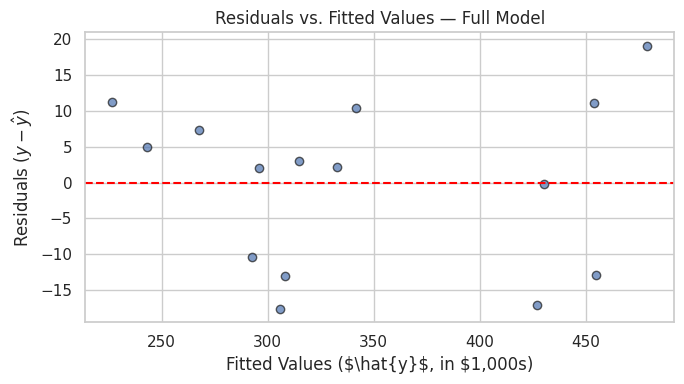

In [ ]:
# Residuals vs. fitted values plot
plt.figure(figsize=(7, 4))
plt.scatter(housing["PredictedPrice"], housing["Residual"],
            alpha=0.7, edgecolors="k")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Fitted Values ($\\hat{y}$, in $1,000s)")
plt.ylabel("Residuals ($y - \\hat{y}$)")
plt.title("Residuals vs. Fitted Values \u2014 Full Model")
plt.tight_layout()
plt.show()

Points scattered randomly around 0 with no obvious pattern are a good sign for our regression assumptions.  
The size of the residuals also matters — larger residuals reflect the overall fit captured by $R^2$.  
**Notebook 3** will teach you exactly what patterns to look for and what they mean.

## 15. Practice questions

1. In this notebook, what is the target variable $y$?
2. What are the three numeric input features?
3. What is the categorical input feature, and why can it not be used directly in `sklearn`?
4. What does one-hot encoding do to the `Location` column?
5. Why do we drop one dummy column? Which one did we drop and why?
6. What is the reference / baseline category in this notebook?
7. What does the coefficient of `Location_Urban` mean in plain language?
8. In Model 1, the `Bedrooms` coefficient is negative. Why? What happened to it in Model 2?
9. In the prediction table with three identical houses, why are the predicted prices different?
10. What is the difference between $R^2$ and Adjusted $R^2$? When should you use Adjusted $R^2$?


## 16. Answer key

Run the cell below to see answers. Numeric answers are generated from the actual fitted model.

In [ ]:
# Auto-computed answers for mini exercises
neg_coefs_m1 = coef_num[coef_num < 0].index.tolist()
largest_change = (coef_full[["SizeSqFt","Bedrooms","Age"]] - coef_num).abs().idxmax()

rural_p = new_houses.loc[new_houses["Location"]=="Rural", "PredictedPrice"].values[0]
suburban_p = new_houses.loc[new_houses["Location"]=="Suburban", "PredictedPrice"].values[0]
urban_p = new_houses.loc[new_houses["Location"]=="Urban", "PredictedPrice"].values[0]
urban_minus_rural = urban_p - rural_p

print("Mini exercise 1:")
print(f"  Negative coef in Model 1: {neg_coefs_m1}  — confounded by location")
print()
print("Mini exercise 2:")
print(f"  Suburban vs Rural (controlled): +${coef_full['Location_Suburban']:.1f}k")
print(f"  Urban    vs Rural (controlled): +${coef_full['Location_Urban']:.1f}k")
print("  Both positive — matches real-world story")
print()
print("Mini exercise 3:")
print(f"  Adj R² Model 1: {adj_r2_num:.4f}")
print(f"  Adj R² Model 2: {adj_r2_full:.4f}")
print("  Increases — Location earns its place")
print()
print("Mini exercise 4:")
print(f"  Largest change: {largest_change}  (flips from negative to positive)")
print("  Caused by confounding — location was hidden in the bedroom effect")
print()
print("Prediction example:")
print(f"  Rural: ${rural_p:.1f}k  Suburban: ${suburban_p:.1f}k  Urban: ${urban_p:.1f}k")
print(f"  Urban-Rural: +${urban_minus_rural:.1f}k  (matches Location_Urban coef)")


NameError: name 'urban_p' is not defined

### Practice question answers

1. The target variable is **`HousePrice`** (in thousands of dollars).
2. The three numeric features are **`SizeSqFt`**, **`Bedrooms`**, and **`Age`**.
3. **`Location`** is the categorical feature. `sklearn` requires numeric input; `Location` contains text.
4. One-hot encoding replaces `Location` with binary (0/1) indicator columns — one per category.
5. We drop one column to avoid perfect redundancy. We dropped **`Location_Rural`** to make Rural the baseline.
6. The baseline / reference category is **`Rural`**.
7. `Location_Urban` means: among houses with the **same size, bedrooms, and age**, an Urban house is predicted to cost about **\$370k more** than a Rural house.
8. In Model 1, `Bedrooms` was negative because Urban houses (few bedrooms) are expensive and Rural houses (many bedrooms) are cheap — the model confused the location effect with the bedroom effect. Once `Location` is added in Model 2, the confounding disappears and `Bedrooms` becomes correctly positive.
9. In the prediction table, the houses have the same size, bedrooms, and age. Their predicted prices differ only because the location dummy variables are different.
10. $R^2$ measures how well **one specific model** fits the data. Adjusted $R^2$ penalises for extra predictors — use it when **comparing models** with different numbers of variables, because $R^2$ always increases when you add variables, even useless ones.


---
## 18. Optional topic: Raw averages vs. controlled comparisons

> **This section is optional.** It goes deeper on one of the most important ideas in multiple regression.  
> You do not need it to use the model or answer the practice questions above.  
> But if you want to understand *why* regression coefficients are more informative than simply comparing group averages, this section explains it clearly.

---

### 18.1 The natural question

You have now fitted Model 2 and found that the `Location_Urban` coefficient is about **+\$370k**.  
That means: holding size, bedrooms, and age constant, an Urban house costs about \$370k more than a Rural house.

But you might ask: why not just compare average prices directly?  
Let us try that first — and then see why it gives a different answer.


In [ ]:
# Step 1: compute the raw average price by location
raw_means = housing.groupby("Location")["HousePrice"].mean().round(1)
raw_means = raw_means.loc[["Rural", "Suburban", "Urban"]]

print("Raw average house price by location:")
print(raw_means)
print()

raw_sub_gap   = raw_means["Suburban"] - raw_means["Rural"]
raw_urban_gap = raw_means["Urban"]    - raw_means["Rural"]

print(f"Raw Urban vs Rural price gap : +{raw_urban_gap:.1f}k")
print(f"Raw Sub   vs Rural price gap : +{raw_sub_gap:.1f}k")

Raw average house price by location:
Location
Rural       267.6
Suburban    318.2
Urban       449.0
Name: HousePrice, dtype: float64

Raw Urban vs Rural price gap : +181.4k
Raw Sub   vs Rural price gap : +50.6k


### 18.2 The problem with raw averages

The raw Urban–Rural price gap is about **+\$181k**.  
But the `Location_Urban` coefficient from Model 2 is about **+\$370k** — more than double.

Why are these numbers so different?

Look at the average characteristics table from Section 4:

| | Rural | Suburban | Urban |
|---|---|---|---|
| Avg size (sq ft) | 2,360 | 1,660 | 1,020 |
| Avg bedrooms | 4.4 | 3.2 | 1.6 |
| Avg age (years) | 25.0 | 13.8 | 6.4 |
| Avg price ($1,000s) | 267.6 | 318.2 | 449.0 |

Urban and Rural houses are **not just different in location** — they are different in everything:

- Urban houses are much **smaller** (1,020 vs 2,360 sq ft)
- Urban houses have far **fewer bedrooms** (1.6 vs 4.4)
- Urban houses are much **newer** (6.4 vs 25 years old)

Here is the key problem:

> Being **smaller** pushes price **down**.  
> Having **fewer bedrooms** pushes price **down**.  
> But being **Urban** pushes price **up** (the location premium).

These forces are working **against each other** in the raw data.  
The raw average shows the net result — location premium minus the size and bedroom penalty.  
So the raw gap of **+\$181k understates the true location premium**.

### 18.3 What the regression coefficient does

The `Location_Urban` coefficient answers a more precise question:

> **"If we compare two houses that are identical in size, bedrooms, and age —  
> but one is Urban and the other is Rural — how much more does the Urban one cost?"**

This is called a **controlled comparison**.  
The model holds size, bedrooms, and age **fixed** and isolates only the price difference due to location.

Because Urban houses are penalised by their smaller size, the raw average understates the true premium.  
The coefficient removes that size penalty and reveals the full location effect: **+\$370k**.


In [ ]:
# Side-by-side comparison
print("Comparison: raw price gap vs. controlled coefficient")
print("-" * 62)
print(f"{'':28s} {'Suburban vs Rural':>18} {'Urban vs Rural':>16}")
print(f"{'Raw average difference':28s} {raw_sub_gap:>+17.1f}k {raw_urban_gap:>+15.1f}k")
print(f"{'Model 2 coefficient':28s} {coef_full['Location_Suburban']:>+17.1f}k {coef_full['Location_Urban']:>+15.1f}k")
print()
print("The controlled coefficient is LARGER than the raw gap.")
print("Urban houses are smaller than Rural houses — that suppresses")
print("their raw price. Once the model removes the size effect,")
print("the true location premium is revealed.")

Comparison: raw price gap vs. controlled coefficient
--------------------------------------------------------------
                             Suburban vs Rural  Urban vs Rural
Raw average difference              +50.6k          +181.4k
Model 2 coefficient                +147.1k          +370.5k

The controlled coefficient is LARGER than the raw gap.
Urban houses are smaller than Rural houses — that suppresses
their raw price. Once the model removes the size effect,
the true location premium is revealed.


### 18.4 Seeing it directly: same house, three locations

The clearest way to understand the controlled comparison is to take **one house** with fixed  
numeric characteristics and predict its price in three different neighbourhoods.  
Because everything except `Location` is identical, any price difference is **purely due to location**.


In [ ]:
# Same house, three locations — confirms coefficients = price differences
same_house = pd.DataFrame({
    "SizeSqFt":         [1500, 1500, 1500],
    "Bedrooms":          [3,    3,    3],
    "Age":               [12,   12,   12],
    "Location_Suburban": [0,    1,    0],
    "Location_Urban":    [0,    0,    1]
})

locations   = ["Rural", "Suburban", "Urban"]
predictions = full_model.predict(same_house)

print("For a house with SizeSqFt=1500, Bedrooms=3, Age=12:")
print("-" * 55)
for loc, p in zip(locations, predictions):
    print(f"  {loc:10s} \u2192 ${p:.1f}k")
print()
print(f"Suburban vs Rural : +${predictions[1] - predictions[0]:.1f}k")
print(f"Urban    vs Rural : +${predictions[2] - predictions[0]:.1f}k")
print()
print(f"These differences match the Location_Suburban (+{coef_full['Location_Suburban']:.1f}k)")
print(f"and Location_Urban (+{coef_full['Location_Urban']:.1f}k) coefficients exactly.")
print("That is the direct meaning of the coefficients.")

For a house with SizeSqFt=1500, Bedrooms=3, Age=12:
-------------------------------------------------------
  Rural     → $148.9k
  Suburban  → $295.9k
  Urban     → $519.4k

Suburban vs Rural : +$147.1k
Urban    vs Rural : +$370.5k

These differences match the Location_Suburban (+147.1k)
and Location_Urban (+370.5k) coefficients exactly.
That is the direct meaning of the coefficients.


### 18.5 Summary of the key insight

| | Suburban vs Rural | Urban vs Rural |
|---|---|---|
| **Raw average difference** | +\$50.6k | +\$181.4k |
| **Model 2 coefficient** | +\$147.1k | +\$370.5k |

The controlled coefficients are larger than the raw gaps because:  
Urban houses are **smaller** and have **fewer bedrooms** than Rural houses.  
Those factors push Urban prices **down** in the raw data, making the gap look smaller than it really is.  
The regression coefficient removes those confounding factors and reveals the true location premium.

> **This is the reason we use multiple regression instead of simple group comparisons.**  
> The coefficient does not just describe what Urban houses cost on average.  
> It describes what it specifically **costs to be Urban** — after accounting for everything else.


## 17. Summary

| Term | Meaning |
|---|---|
| Multiple linear regression | Regression with two or more input variables |
| $b_0$ | Intercept — predicted $y$ when all $x_i = 0$ |
| $b_i$ | Slope — change in $\hat{y}$ per unit increase in $x_i$, **holding all others constant** |
| Confounding | When a missing variable distorts the estimated effect of another variable |
| One-hot encoding / dummy variables | Converts a categorical variable into binary (0/1) columns |
| Baseline / reference category | The dropped dummy — all other dummy coefficients are interpreted relative to it |
| Controlled comparison | The coefficient isolates the effect of one variable after accounting for all others |
| $R^2$ | Proportion of variation in $y$ explained — use to describe **one model** |
| Adjusted $R^2$ | $R^2$ penalised for extra predictors — use to **compare models** |

### Key formulas

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \cdots + b_p x_p$$

$$\bar{R}^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$$

### Workflow for including a categorical variable

1. Use `pd.get_dummies()` with `drop_first=False` to create all dummy columns
2. Manually drop the baseline category column
3. Fit the model using the encoded feature matrix
4. When predicting new data, encode it in the **same way** before calling `.predict()`

---

**Next:** Notebook 3 covers **linear regression assumptions** — how to check whether your model is trustworthy using residual plots, Q-Q plots, and other diagnostic tools.